**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


**Load Dataset**

**To view the first 5 rows**

In [ ]:
df = pd.read_csv("/content/StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**To view the last 5 rows**

In [ ]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


**Statistical Summary**

In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Dataset structure**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


**Check for Null values**

In [ ]:
df.isnull()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


**To view the total null values in each column**

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


To view the dimensions

In [ ]:
df.shape

(1000, 8)

**One hot encoding**

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()


,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


**Create Target Variable (Final Score)**

In [ ]:
df["final_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3


**Encode Categorical Features**

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,final_score
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True,72.666667
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False,82.333333
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True,92.666667
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True,49.333333
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True,76.333333


In [ ]:
df.shape

(1000, 16)

**Feature Selection**

In [ ]:
X = df.drop(
    ["math score", "reading score", "writing score", "final_score"],
    axis=1
)

y = df["final_score"]


**Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Train Model**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

**Predictions**

In [ ]:
y_pred = model.predict(X_test)


**Evaluation**

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MSE: 179.60234233623538
RMSE: 13.401579844788277
R² Score: 0.16217185763155217


**Coefficient Analysis**

In [ ]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coeff_df.sort_values(by="Coefficient", ascending=False)


,Coefficient
lunch_standard,4.380763
race/ethnicity_group E,2.098596
race/ethnicity_group D,1.642580
parental level of education_bachelor's degree,1.138048
parental level of education_master's degree,0.453474
race/ethnicity_group C,0.429938
race/ethnicity_group B,-0.054994
parental level of education_some college,-0.358055
parental level of education_some high school,-1.233027
parental level of education_high school,-1.858405


**Ridge & Lasso**

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("Ridge R²:", ridge.score(X_test, y_test))
print("Lasso R²:", lasso.score(X_test, y_test))


Ridge R²: 0.16211599511083097
Lasso R²: 0.15571024206694484


**Visualization**



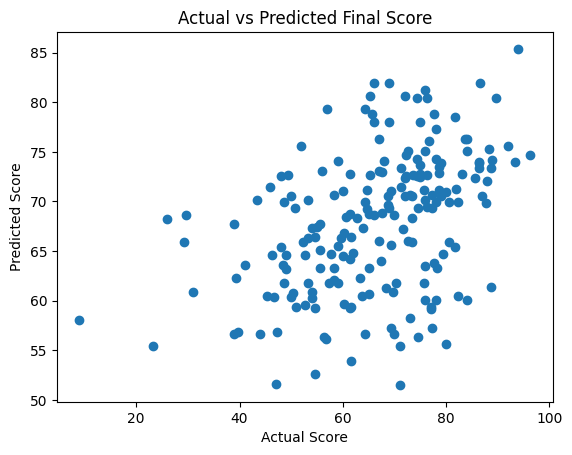

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Final Score")
plt.show()


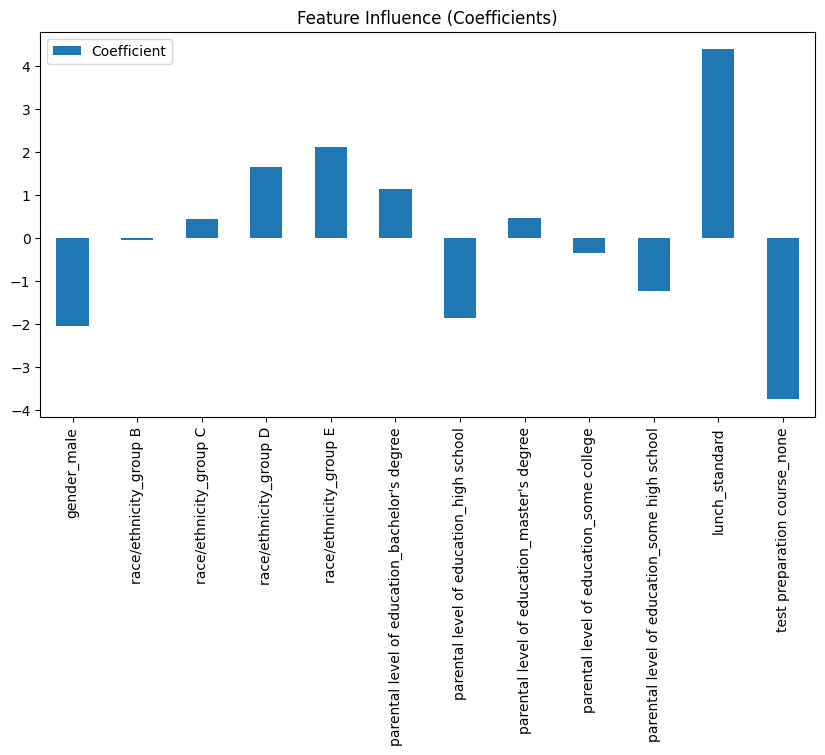

In [ ]:
coeff_df.plot(kind="bar", figsize=(10,5))
plt.title("Feature Influence (Coefficients)")
plt.show()


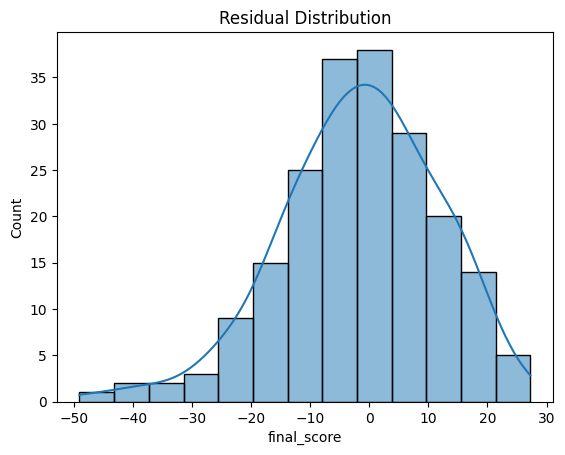

In [ ]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


**SCENARIO 2 – POLYNOMIAL REGRESSION (Auto MPG)**

**Import Libraries**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures


**Load Dataset**

In [ ]:
auto = pd.read_csv("auto-mpg.csv")
auto.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


**Dataset structure**

In [ ]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


**Clean Dataset**

In [ ]:
# Convert horsepower to numeric

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')


**Select Features**

In [55]:
X = auto[["horsepower"]]   # Independent variable
y = auto["mpg"]            # Target variable


In [56]:
X.fillna(X.mean(), inplace=True)


/tmp/ipython-input-1183906534.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Train Test Split**

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [59]:
def polynomial_model(degree):
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    return y_train_pred, y_test_pred


**Loop Polynomial Degrees**

In [60]:
results = {}

for d in [2, 3, 4]:
    y_train_pred, y_test_pred = polynomial_model(d)
    results[d] = (y_train_pred, y_test_pred)


In [61]:
performance = []

for degree, (y_train_pred, y_test_pred) in results.items():
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_test_pred)

    performance.append([degree, mse, rmse, r2])

perf_df = pd.DataFrame(
    performance,
    columns=['Degree', 'MSE', 'RMSE', 'R2 Score']
)

perf_df


,Degree,MSE,RMSE,R2 Score
0,2,18.416968,4.291499,0.639170
1,3,18.460267,4.296541,0.638322
2,4,18.268227,4.274135,0.642084


**Ridge Regularization**

In [62]:
poly = PolynomialFeatures(degree=4)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

ridge_pred = ridge.predict(X_test_poly)

print("Ridge R²:", r2_score(y_test, ridge_pred))


Ridge R²: 0.6413187331941297


**Visualization Curve**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


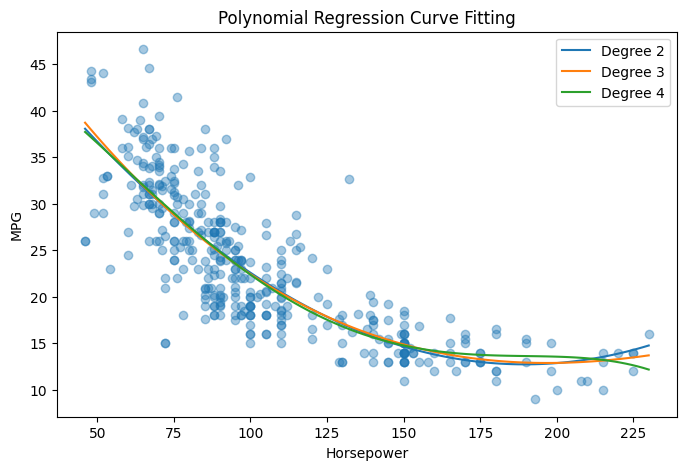

In [63]:
X_plot = np.linspace(X.min(), X.max(), 100)
X_plot_scaled = scaler.transform(X_plot)

plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.4)

for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly_plot = poly.fit_transform(X_plot_scaled)

    model = LinearRegression()
    model.fit(poly.fit_transform(X_scaled), y)

    y_plot = model.predict(X_poly_plot)
    plt.plot(X_plot, y_plot, label=f"Degree {degree}")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression Curve Fitting")
plt.legend()
plt.show()


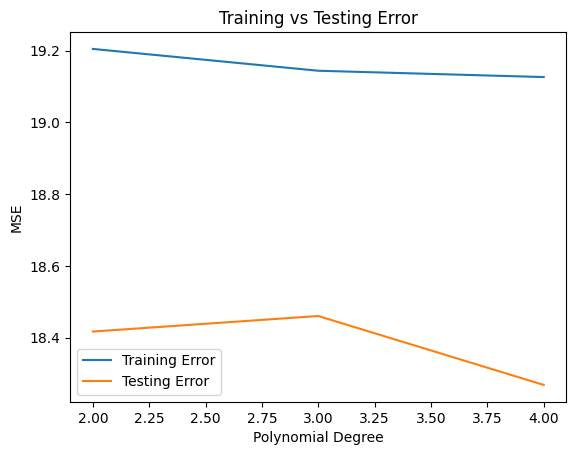

In [64]:
train_errors = []
test_errors = []

for degree in [2, 3, 4]:
    y_train_pred, y_test_pred = results[degree]

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

plt.plot([2,3,4], train_errors, label="Training Error")
plt.plot([2,3,4], test_errors, label="Testing Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Testing Error")
plt.legend()
plt.show()
